In [2]:
import pandas as pd

df = pd.read_csv("../data/bpi_2017_cleaned.csv")

df.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(1202267, 19)

In [4]:
df.columns.tolist()

['Action',
 'org:resource',
 'concept:name',
 'EventOrigin',
 'EventID',
 'lifecycle:transition',
 'time:timestamp',
 'case:LoanGoal',
 'case:ApplicationType',
 'case:concept:name',
 'case:RequestedAmount',
 'FirstWithdrawalAmount',
 'NumberOfTerms',
 'Accepted',
 'MonthlyCost',
 'Selected',
 'CreditScore',
 'OfferedAmount',
 'OfferID']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Action                 1202267 non-null  object 
 1   org:resource           1202267 non-null  object 
 2   concept:name           1202267 non-null  object 
 3   EventOrigin            1202267 non-null  object 
 4   EventID                1202267 non-null  object 
 5   lifecycle:transition   1202267 non-null  object 
 6   time:timestamp         1202267 non-null  object 
 7   case:LoanGoal          1202267 non-null  object 
 8   case:ApplicationType   1202267 non-null  object 
 9   case:concept:name      1202267 non-null  object 
 10  case:RequestedAmount   1202267 non-null  float64
 11  FirstWithdrawalAmount  42995 non-null    float64
 12  NumberOfTerms          42995 non-null    float64
 13  Accepted               42995 non-null    object 
 14  MonthlyCost       

In [6]:
df["concept:name"].value_counts().head(20)

concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Accepted                   31509
A_Create Application         31509
A_Concept                    31509
A_Complete                   31362
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
A_Pending                    17228
A_Cancelled                  10431
Name: count, dtype: int64

In [7]:
df["Action"].value_counts()

Action
statechange    358940
Obtained       255387
Created        223608
Released       215402
Deleted        148930
Name: count, dtype: int64

In [8]:
df["EventOrigin"].value_counts()

EventOrigin
Workflow       768823
Application    239595
Offer          193849
Name: count, dtype: int64

In [9]:
[c for c in df.columns if "case" in c.lower()]

['case:LoanGoal',
 'case:ApplicationType',
 'case:concept:name',
 'case:RequestedAmount']

In [10]:
case_col = "case:concept:name"

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")

cases = df.groupby(case_col).agg(
    start_time=("time:timestamp", "min"),
    end_time=("time:timestamp", "max"),
    num_events=("concept:name", "count"),
    num_unique_activities=("concept:name", "nunique"),
    loan_goal=("case:LoanGoal", "first"),
    application_type=("case:ApplicationType", "first"),
    requested_amount=("case:RequestedAmount", "first"),
)

cases["duration_days"] = (
    cases["end_time"] - cases["start_time"]
).dt.total_seconds() / 86400

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days
case:concept:name,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500


In [11]:
cases.shape

(31509, 8)

In [12]:
cases.describe(include="all")

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days
count,31509,31509,31509.000000,31509.000000,31509,31509,31509.000000,31509.000000
unique,NaN,NaN,NaN,NaN,14,2,NaN,NaN
top,NaN,NaN,NaN,NaN,Car,New credit,NaN,NaN
freq,NaN,NaN,NaN,NaN,9328,28120,NaN,NaN
mean,2016-07-08 22:53:09.424832512+00:00,2016-07-30 20:28:35.347781632+00:00,38.156305,15.532324,NaN,NaN,16233.743989,21.899606
min,2016-01-01 09:51:15.304000+00:00,2016-01-06 08:50:04.878000+00:00,10.000000,8.000000,NaN,NaN,0.000000,0.002327
25%,2016-04-12 10:23:16.456000+00:00,2016-05-03 10:37:44.344999936+00:00,25.000000,13.000000,NaN,NaN,6000.000000,11.324672
50%,2016-07-14 11:50:00.176000+00:00,2016-08-06 12:06:18.169999872+00:00,35.000000,16.000000,NaN,NaN,12500.000000,19.087739
75%,2016-10-03 10:47:09.792999936+00:00,2016-10-24 06:50:16.305999872+00:00,47.000000,18.000000,NaN,NaN,21000.000000,31.495729
max,2016-12-31 21:37:53.216000+00:00,2017-02-01 14:11:03.499000+00:00,180.000000,21.000000,NaN,NaN,450000.000000,286.072438


In [13]:
activity_counts = (
    df.pivot_table(
        index=case_col,
        columns="concept:name",
        values="EventID",
        aggfunc="count",
        fill_value=0,
    )
)

activity_counts.columns = [
    "activity_" + col.lower().replace(" ", "_").replace("-", "_")
    for col in activity_counts.columns
]

cases = cases.join(activity_counts)

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days,activity_a_accepted,activity_a_cancelled,...,activity_o_sent_(mail_and_online),activity_o_sent_(online_only),activity_w_assess_potential_fraud,activity_w_call_after_offers,activity_w_call_incomplete_files,activity_w_complete_application,activity_w_handle_leads,activity_w_personal_loan_collection,activity_w_shortened_completion_,activity_w_validate_application
case:concept:name,,,,,,,,,,,,,,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593,1,1,...,1,0,0,6,0,4,2,0,0,0
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037,1,0,...,1,0,0,4,0,3,2,0,0,4
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242,1,1,...,1,0,0,6,0,3,0,0,0,0
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359,1,0,...,1,0,0,6,6,5,2,0,0,7
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500,1,0,...,1,0,0,6,8,3,2,0,0,16


In [14]:
cases["has_incomplete_files"] = (
    cases.get("activity_w_call_incomplete_files", 0) > 0
).astype(int)

cases["num_incomplete_file_calls"] = cases.get(
    "activity_w_call_incomplete_files", 0
)

cases["num_after_offer_calls"] = cases.get(
    "activity_w_call_after_offers", 0
)

cases["num_validation_events"] = cases.get(
    "activity_w_validate_application", 0
)

cases["num_offer_events"] = cases.get(
    "activity_o_create_offer", 0
)

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days,activity_a_accepted,activity_a_cancelled,...,activity_w_complete_application,activity_w_handle_leads,activity_w_personal_loan_collection,activity_w_shortened_completion_,activity_w_validate_application,has_incomplete_files,num_incomplete_file_calls,num_after_offer_calls,num_validation_events,num_offer_events
case:concept:name,,,,,,,,,,,,,,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593,1,1,...,4,2,0,0,0,0,0,6,0,1
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037,1,0,...,3,2,0,0,4,0,0,4,4,1
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242,1,1,...,3,0,0,0,0,0,0,6,0,1
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359,1,0,...,5,2,0,0,7,1,6,6,7,1
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500,1,0,...,3,2,0,0,16,1,8,6,16,1


In [15]:
delay_threshold = cases["duration_days"].quantile(0.75)

cases["is_delayed"] = (
    cases["duration_days"] > delay_threshold
).astype(int)

delay_threshold, cases["is_delayed"].value_counts(normalize=True)

(np.float64(31.495728541666665),
 is_delayed
 0    0.750008
 1    0.249992
 Name: proportion, dtype: float64)

In [18]:
cases[["duration_days", "num_events", "num_unique_activities", "is_delayed"]].describe()

,duration_days,num_events,num_unique_activities,is_delayed
count,31509.000000,31509.000000,31509.000000,31509.000000
mean,21.899606,38.156305,15.532324,0.249992
std,13.169233,16.715308,2.493093,0.433015
min,0.002327,10.000000,8.000000,0.000000
25%,11.324672,25.000000,13.000000,0.000000
50%,19.087739,35.000000,16.000000,0.000000
75%,31.495729,47.000000,18.000000,0.000000
max,286.072438,180.000000,21.000000,1.000000


In [19]:
features = [
    "num_events",
    "num_unique_activities",
    "requested_amount",
    "num_incomplete_file_calls",
    "num_after_offer_calls",
    "num_validation_events",
    "num_offer_events",
]

X = cases[features]
y = cases["is_delayed"]

X.head()

,num_events,num_unique_activities,requested_amount,num_incomplete_file_calls,num_after_offer_calls,num_validation_events,num_offer_events
case:concept:name,,,,,,,
Application_1000086665,22,13,5000.0,0,6,0,1
Application_1000158214,25,16,12500.0,0,4,4,1
Application_1000311556,18,11,45000.0,0,6,0,1
Application_1000334415,40,18,5000.0,6,6,7,1
Application_1000339879,51,18,37500.0,8,6,16,1


In [20]:
X.isnull().sum()

num_events                   0
num_unique_activities        0
requested_amount             0
num_incomplete_file_calls    0
num_after_offer_calls        0
num_validation_events        0
num_offer_events             0
dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8406854966677245
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4727
           1       0.70      0.65      0.67      1575

    accuracy                           0.84      6302
   macro avg       0.79      0.78      0.78      6302
weighted avg       0.84      0.84      0.84      6302



In [25]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values(ascending=False)

num_events                   0.240049
num_validation_events        0.211561
requested_amount             0.199078
num_unique_activities        0.149810
num_incomplete_file_calls    0.098277
num_after_offer_calls        0.066740
num_offer_events             0.034484
dtype: float64

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8525864804823865
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4727
           1       0.71      0.69      0.70      1575

    accuracy                           0.85      6302
   macro avg       0.80      0.80      0.80      6302
weighted avg       0.85      0.85      0.85      6302



ExactExplainer explainer: 1001it [00:18, 34.73it/s]                         


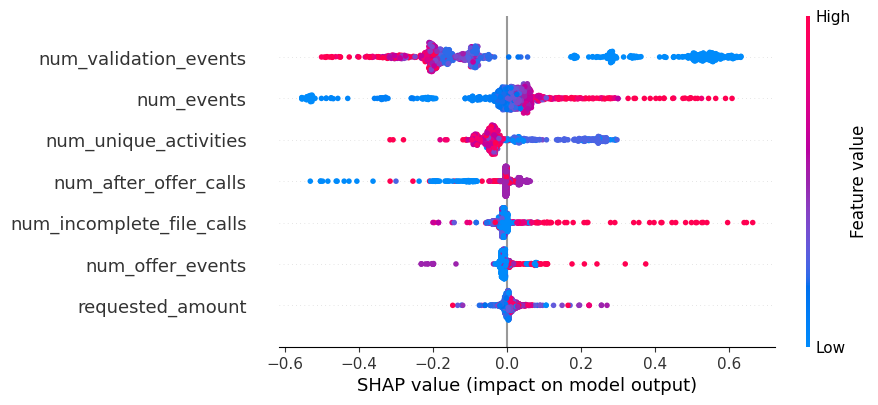

In [30]:
import shap

X_train_sample = X_train.sample(1000, random_state=42)
X_test_sample = X_test.sample(1000, random_state=42)

explainer = shap.Explainer(xgb.predict, X_train_sample)
shap_values = explainer(X_test_sample)

shap.plots.beeswarm(shap_values)